In [25]:
import pandas as pd
import altair as alt

In [26]:
ls | grep csv

hello_geoffrey.csv
test_streamflow_output_swe=0.csv
test_streamflow_output_swe=1.csv
test_streamflow_output_swe=f(t).csv
test_swe_output_swe=0.csv
test_swe_output_swe=1.csv
test_swe_output_swe=f(t).csv


In [45]:
df0 = pd.read_csv("test_streamflow_output_swe=0.csv").rename(columns={
    'tci_0': 'zone1_swe_zero',
    'tci_1': 'zone2_swe_zero'
})
df1 = pd.read_csv("test_streamflow_output_swe=1.csv").rename(columns={
    'tci_0': 'zone1_swe_one',
    'tci_1': 'zone2_swe_one'
})
df2 = pd.read_csv("test_streamflow_output_swe=f(t).csv").rename(columns={
    'tci_0': 'zone1_swe_f(t)',
    'tci_1': 'zone2_swe_f(t)'
})
df_q = df0.set_index('datetime').join(
    df1.set_index('datetime')
).join(
    df2.set_index('datetime')
)

In [52]:
df0 = pd.read_csv("test_swe_output_swe=0.csv").rename(columns={
    '0': 'zone1_swe_zero',
    '1': 'zone2_swe_zero'
})
df1 = pd.read_csv("test_swe_output_swe=1.csv").rename(columns={
    '0': 'zone1_swe_one',
    '1': 'zone2_swe_one'
})
df2 = pd.read_csv("test_swe_output_swe=f(t).csv").rename(columns={
    '0': 'zone1_swe_f(t)',
    '1': 'zone2_swe_f(t)'
})
df_swe = df0.set_index('datetime').join(
    df1.set_index('datetime')
).join(
    df2.set_index('datetime')
)

In [53]:
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [54]:
alt.renderers.enable('html')


RendererRegistry.enable('html')

In [58]:
q_chart = alt.Chart(df_q.reset_index().head(1460)).mark_line().transform_fold(
    ['zone1_swe_zero', 'zone1_swe_one', 'zone1_swe_f(t)']
).encode(
    alt.X('datetime:T').title('Water Year 2003'),
    alt.Y('value:Q').title("Streamflow (cfs)"),
    alt.Color('key:N')
).properties(width=600, height=150)

swe_chart = alt.Chart(df_swe.reset_index().head(1460)).mark_line().transform_fold(
    ['zone1_swe_zero', 'zone1_swe_one', 'zone1_swe_f(t)']
).encode(
    alt.X('datetime:T').title('Water Year 2003'),
    alt.Y('value:Q').title('SWE (mm)'),
    alt.Color('key:N')
).properties(width=600, height=150)

(swe_chart & q_chart).interactive()

/Users/elischwat/miniforge3/envs/sublimationofsnow/lib/python3.14/site-packages/altair/vegalite/v6/api.py:3804: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  dct = self.to_dict(context={"pre_transform": False})


alt.VConcatChart(...)

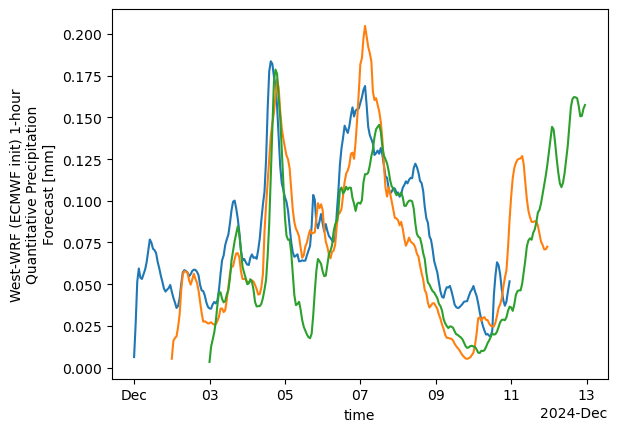

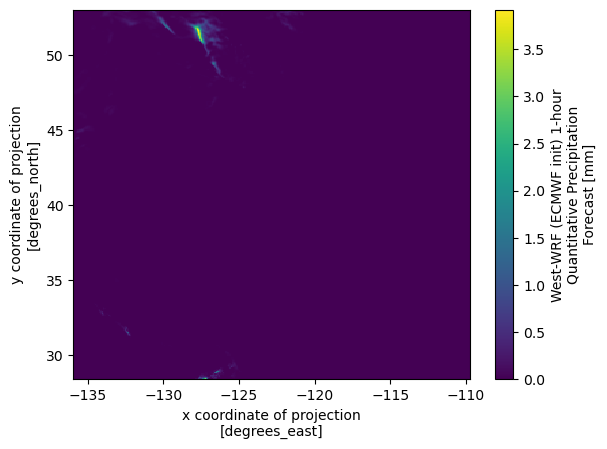